#Entrega 6
# UNIVERSIDAD ICESI
# MAESTRIA EN  IA APLICADA
## Nombres:

#### Diego Agudelo
#### Angelica Maria Mayor
#### Freddy Mauricio Gutierrez
#### Carlos Alberto Martinez Ramirez
#### Wilman Quiñonez



## Retrieval-Augmented Generation (RAG), Ollama y ChatBots
References
Newtral Simple RAG Example
Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks
Natural Language Processing with Transformers: Building Language Applications With Hugging Face
Hugging Face Transformers

## Chatbot RAG en Español con **Llama 3** + **FAISS** + **Gradio** (Colab)

La idea es construir un chatbot que responda en español usando la técnica RAG (recuperar info + generar respuesta). Lo vamos a correr en Google Colab.

Dataset: **mapama247/wikihow_es** (Hugging Face)

Usamos un corpus de WikiHow en español.

Pasos: descripción de variables → creación de vector store → DocumentRetriever → LLM (Llama 3) → definición del chatbot → interfaz con Gradio.
Comentario:

1. Descripción de variables: primero miro qué columnas trae el dataset (títulos, pasos, url, etc.) para saber qué texto voy a indexar.

2. Vector store (FAISS): convierto los textos en vectores (embeddings) y los guardo en un índice para buscar rápido por similitud.

3. DocumentRetriever: con una pregunta del usuario, traigo los top-k fragmentos más parecidos.

4. LLM (Llama 3): el modelo grande de lenguaje genera la respuesta usando esos fragmentos como contexto.

5. Definición del chatbot: conecto “retriever + LLM” en una función RAG.

6. Gradio: creo una interfaz web sencilla para chatear y probarlo.


## 1. **Instalación de dependencias**

In [ ]:
!pip -q install --upgrade pip
!pip -q install datasets pandas faiss-cpu sentence-transformers huggingface_hub llama-cpp-python gradio==4.* pydantic==2.*

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.38.0 requires websockets<15.1.0,>=13.0.0, but you have websockets 12.0 which is incompatible.
yfinance 0.2.66 requires websockets>=13.0, but you have websockets 12.0 which is incompatible.
dataproc-spark-connect 0.8.3 requires websockets>=14.0, but you have websockets 12.0 which is incompatible.
google-adk 1.14.1 requires websockets<16.0.0,>=15.0.1, but you have websockets 12.0 which is incompatible.


Preparamos todo el ambiente de Colab con las librerías necesarias para cargar datos, vectorizar, usar Llama 3 y crear la interfaz del chatbot.

### 2. **Cargar `mapama247/wikihow_es` y describir variables**

In [ ]:
from datasets import load_dataset
import pandas as pd

# Carga del split principal (ajusta si tu dataset tiene otros splits)
ds = load_dataset("mapama247/wikihow_es", split="train")

print("Tamaño del split:", len(ds))
print("Columnas:", ds.column_names)

# Vista previa
df = ds.to_pandas().head(5)
display(df)

# Descripción flexible de columnas
def describe_columns(dataset):
    info_rows = []
    for col in dataset.column_names:
        sample_vals = dataset[col][:50]
        non_null = [v for v in sample_vals if v is not None]
        sample = non_null[0] if non_null else None
        info_rows.append({
            "columna": col,
            "tipo_detectado": type(sample).__name__ if sample is not None else "NoneType",
            "nulos_%(aprox)": round(100*(1-len(non_null)/max(1,len(sample_vals))),2),
            "ejemplo": str(sample)[:120] if sample is not None else None
        })
    return pd.DataFrame(info_rows)

desc = describe_columns(ds)
display(desc)

README.md: 0.00B [00:00, ?B/s]

all/train-00000-of-00001.parquet:   0%|          | 0.00/38.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7380 [00:00<?, ? examples/s]

Tamaño del split: 7380
Columnas: ['category', 'question', 'introduction', 'answers', 'short_answers', 'url', 'num_answers', 'num_refs', 'expert_author']


,category,question,introduction,answers,short_answers,url,num_answers,num_refs,expert_author
0,cuidado-y-estilo-personal,¿Cómo usar accesorios de joyería?,Los accesorios pueden hacer que cualquier atue...,[Método 1: Escoger joyas según tus intereses s...,[Método 1: Escoger joyas según tus intereses s...,https://es.wikihow.com/usar-accesorios-de-joye...,2,17,True
1,salud,¿Cómo ser productivo en el trabajo cuando está...,Cuando te sientes desanimado a causa de la dep...,[Método 1: Hacer que las tareas sean más senci...,[Método 1: Hacer que las tareas sean más senci...,https://es.wikihow.com/ser-productivo-en-el-tr...,4,12,True
2,carreras-y-educación,¿Cómo ser comediante?,Presentar un acto de comedia es una excelente ...,[Método 1: Desarrollar confianza y sentido del...,[Método 1: Desarrollar confianza y sentido del...,https://es.wikihow.com/ser-comediante,3,22,True
3,computadoras-y-electrónica,¿Cómo transferir fotos de una cámara a una com...,Las cámaras digitales han liberado al fotógraf...,[Método 1: Conexión directa\n\n1. Usa un cable...,[Método 1: Conexión directa\n1. Usa un cable U...,https://es.wikihow.com/transferir-fotos-de-una...,6,0,True
4,cuidado-y-estilo-personal,¿Cómo sentirse bella por dentro y por fuera?,La belleza es una palabra con miles de descrip...,[Sigue los siguientes pasos:\n\n1. Ve a la cam...,[Sigue los siguientes pasos:\n1. Ve a la cama ...,https://es.wikihow.com/sentirse-bella-por-dent...,1,0,False


,columna,tipo_detectado,nulos_%(aprox),ejemplo
0,category,str,0.0,cuidado-y-estilo-personal
1,question,str,0.0,¿Cómo usar accesorios de joyería?
2,introduction,str,0.0,Los accesorios pueden hacer que cualquier atue...
3,answers,list,0.0,['Método 1: Escoger joyas según tus intereses ...
4,short_answers,list,0.0,['Método 1: Escoger joyas según tus intereses ...
5,url,str,0.0,https://es.wikihow.com/usar-accesorios-de-joye...
6,num_answers,int,0.0,2
7,num_refs,int,0.0,17
8,expert_author,bool,0.0,True


cargamos el dataset, hacemos una vista previa de algunas filas y creamos una tabla que describe las columnas (su tipo, nulos y ejemplo).

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Gráfico 1: Tabla con la info de las columnas
fig_table = go.Figure(data=[go.Table(
    header=dict(values=list(desc.columns), fill_color="lightgrey", align="left"),
    cells=dict(values=[desc[c] for c in desc.columns], align="left")
)])
fig_table.update_layout(title="Descripción de las columnas del dataset")
fig_table.show()

# Gráfico 2: Conteo de tipos detectados
type_counts = desc["tipo_detectado"].value_counts().reset_index()
type_counts.columns = ["tipo_detectado", "count"]  # renombro columnas
fig_types = px.bar(
    type_counts,
    x="tipo_detectado", y="count",
    labels={"tipo_detectado":"Tipo de dato", "count":"Cantidad"},
    title="Cantidad de columnas por tipo de dato"
)
fig_types.show()

# Gráfico 3: Porcentaje de nulos por columna
fig_nulls = px.bar(
    desc, x="columna", y="nulos_%(aprox)",
    title="Porcentaje de nulos por columna",
    labels={"columna":"Columna", "nulos_%(aprox)":"% de nulos"}
)
fig_nulls.show()


In [ ]:
px.bar(ds.to_pandas()['category'].value_counts().head(20).reset_index(), x='category', y='count', title='Top 20 categorías').show()



La gráfica muestra las 20 categorías con más artículos en WikiHow en español.

Las que tienen más artículos son:

1. computadoras-y-electrónica (~820 artículos)

2. salud (~800 artículos)

3. pasatiempos y cuidado-y-estilo-personal (alrededor de 720 cada una).

4. Otras categorías importantes: carreras-y-educación, en-la-casa-y-el-jardín, finanzas-y-negocios y comida-y-diversión (todas entre 450–550 artículos).

5. Las categorías con menos artículos en el top 20 son vida-familiar, viajes, automóviles-y-otros-vehículos y días-de-fiesta-y-tradiciones (por debajo de 150 artículos).

## 3. Preprocesamiento **Documentos** + **Chunking**

In [ ]:
import re
from typing import List, Dict

TEXT_CANDIDATES = ["text","content","article","body","summary","intro","steps","paragraphs","sentences","description"]
TITLE_CANDIDATES = ["title","titulo","headline","heading","name"]
URL_CANDIDATES = ["url","source","href","link"]

def extract_text_fields(row: Dict) -> Dict:
    cols = row.keys()
    # Use 'question' as title if available
    title = next((row[c] for c in ["question"] if c in cols), None)
    url = next((row[c] for c in URL_CANDIDATES if c in cols), None)

    parts = []
    if title:
        parts.append(str(title))

    # Add 'introduction' if available
    if "introduction" in cols and row["introduction"]:
        parts.append(str(row["introduction"]))

    # Add 'answers' or 'short_answers' if available
    for c in ["answers","short_answers"]:
        if c in cols and row[c]:
            st = row[c]
            if isinstance(st, list):
                parts.append("\n".join([str(s) for s in st]))
            else:
                parts.append(str(st))

    full_text = "\n".join([p for p in parts if p and p.strip()])
    return {"title": title, "url": url, "text": full_text.strip()}

def simple_chunk(text: str, max_chars: int = 300, overlap: int = 100) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    chunks = []
    start = 0
    while start < len(text):
        end = min(len(text), start + max_chars)
        chunks.append(text[start:end])
        if end == len(text):
            break
        start = max(0, end - overlap)
    return chunks

docs = []
for i in range(len(ds)):
    row = ds[i]
    p = extract_text_fields(row)
    if not p["text"]:
        continue
    chunks = simple_chunk(p["text"], max_chars=300, overlap=100)
    for j, ch in enumerate(chunks):
        docs.append({
            "doc_id": f"{i}-{j}",
            "title": p["title"],
            "url": p["url"],
            "text": ch
        })

print("Docs creados:", len(docs))
print(docs[0] if docs else "Sin docs")

Docs creados: 341287
{'doc_id': '0-0', 'title': '¿Cómo usar accesorios de joyería?', 'url': 'https://es.wikihow.com/usar-accesorios-de-joyer%C3%ADa', 'text': '¿Cómo usar accesorios de joyería? Los accesorios pueden hacer que cualquier atuendo luzca genial. Pueden transformar un atuendo aburrido en uno elegante o hacer que un atuendo formal luzca más casual. No hay ninguna razón para no hacer que tus prendas de vestir luzcan más interesantes con algunas jo'}


Este bloque convierte cada artículo de WikiHow en varios documentos cortos (chunks) con título y URL. Así luego podemos vectorizar cada fragmento y buscar rápido en FAISS cuando un usuario haga una pregunta.
1. Define listas de candidatos
2. Función extract_text_fields(row)
3. Función simple_chunk(text)
4. Loop principal
5. Salida final

## 4. Creando el **Vector Store** con FAISS

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss, numpy as np
import pickle, os

EMB_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(EMB_MODEL)

texts = [d["text"] for d in docs]
embs = embedder.encode(texts, show_progress_bar=True, normalize_embeddings=True)
embs = np.array(embs).astype("float32")

index = faiss.IndexFlatIP(embs.shape[1])
index.add(embs)

os.makedirs("artifacts", exist_ok=True)
faiss.write_index(index, "artifacts/wikihow.index")
with open("artifacts/wikihow_meta.pkl","wb") as f:
    pickle.dump(docs, f)
with open("artifacts/embedding_model.txt","w") as f:
    f.write(EMB_MODEL)

print("Index size:", index.ntotal)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10666 [00:00<?, ?it/s]

Index size: 341287


Este bloque convierte todos los chunks de WikiHow en embeddings, los mete en un índice FAISS y guarda todo en disco. Con esto ya tenemos el “cerebro” para buscar los fragmentos más parecidos a una pregunta del usuario.

Se completó exitosamente la descarga y configuración del modelo de Sentence Transformers. Se cargaron todos los archivos necesarios (configuraciones, tokenizer, pesos en model.safetensors, README y metadatos). El archivo principal del modelo tiene un tamaño de 471 MB y se descargó en unos 15 segundos con buena velocidad. Finalmente, se procesaron 2.915 lotes en aproximadamente 3 minutos y 44 segundos, confirmando que el modelo quedó indexado y listo para su uso.

## 5. `DocumentRetriever`

In [ ]:
import pickle, faiss, numpy as np
from sentence_transformers import SentenceTransformer

index = faiss.read_index("artifacts/wikihow.index")
with open("artifacts/wikihow_meta.pkl","rb") as f:
    docs = pickle.load(f)
with open("artifacts/embedding_model.txt") as f:
    EMB_MODEL = f.read().strip()
embedder = SentenceTransformer(EMB_MODEL)

def retrieve(query: str, k: int = 5):
    q_emb = embedder.encode([query], normalize_embeddings=True)
    q_emb = np.array(q_emb).astype("float32")
    scores, idxs = index.search(q_emb, k)
    results = []
    for score, idx in zip(scores[0], idxs[0]):
        if idx == -1:
            continue
        results.append({"score": float(score), **docs[idx]})
    return results

# Prueba
retrieve("¿Cómo limpiar vidrios sin dejar marcas?", k=3)

[{'score': 0.823135495185852,
  'doc_id': '4737-25',
  'title': '¿Cómo cortar vidrio templado?',
  'url': 'https://es.wikihow.com/cortar-vidrio-templado',
  'text': 'odón limpio y sin pelusa. Limpiar el vidrio te asegurará de que el corte sea liso y preciso. Puedes comprar el limpiador de ventanas en cualquier ferretería o en un supermercado. 2. Ponte un par de gafas de protección y guantes de cuero para protegerte. Después de que el vidrio esté templado, ya no '},
 {'score': 0.8212392330169678,
  'doc_id': '2919-28',
  'title': '¿Cómo cambiar el vidrio roto de un marco de fotos?',
  'url': 'https://es.wikihow.com/cambiar-el-vidrio-roto-de-un-marco-de-fotos',
  'text': ' limpiador para ventanas o gafas en el pedazo de vidrio y límpialo con una toalla de papel. Asegúrate que ninguno de los lados tenga rayas. Si no tienes un limpiador de vidrio, es suficiente con que utilices vinagre y agua tibia. No uses un paño que dejes fibras pequeñas. Debido a que tendrás que so'},
 {'score': 0.8010

Esto nos permite buscar y recuperar artículos de WikiHow basados en similitud semántica con consultas en lenguaje natural.
1. Carga de recursos
2. Función retrieve
3. Prueba:

Se ejecuta una consulta de ejemplo: “¿Cómo limpiar vidrios sin dejar marcas?”, solicitando los 3 resultados más relevantes.

## 6.  Implementando el **LLM**

In [ ]:
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

# Cambia estas variables si prefieres otro archivo GGUF compatible.
REPO_ID = "MaziyarPanahi/Meta-Llama-3-8B-Instruct-GGUF"
FILENAME = "Meta-Llama-3-8B-Instruct.Q4_K_M.gguf"

try:
    model_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME, local_dir="models")
    chat_format = "llama-3"
    print("Modelo Llama‑3 descargado:", model_path)
except Exception as e:
    print("Fallo Llama‑3, usando TinyLlama de respaldo...", e)
    REPO_ID = "TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF"
    FILENAME = "tinyllama-1.1b-chat-v1.0.Q5_K_M.gguf"
    model_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME, local_dir="models")
    chat_format = "chatml"  # formato compatible con TinyLlama
    print("Respaldo TinyLlama:", model_path)

llm = Llama(
    model_path=model_path,
    n_ctx=4096,
    n_threads=8,
    chat_format=chat_format,
    verbose=False
)

def generate_answer(system_prompt: str, user_prompt: str, temperature: float = 0.2, max_tokens: int = 512):
    messages = [
        {"role":"system", "content": system_prompt},
        {"role":"user", "content": user_prompt}
    ]
    out = llm.create_chat_completion(
        messages=messages,
        temperature=temperature,
        max_tokens=max_tokens
    )
    return out["choices"][0]["message"]["content"]

Meta-Llama-3-8B-Instruct.Q4_K_M.gguf:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Modelo Llama‑3 descargado: models/Meta-Llama-3-8B-Instruct.Q4_K_M.gguf


llama_context: n_ctx_per_seq (4096) < n_ctx_train (8192) -- the full capacity of the model will not be utilized


El código construye un mini-pipeline de chat con modelos LLaMA en formato GG
1. Primero intenta descargar automáticamente el modelo grande Meta-Llama-3-8B-Instruct desde Hugging Face.
2. Una vez descargado, el modelo se inicializa con parámetros de ejecución: contexto de hasta 4096 tokens, 8 hilos de procesamiento y un formato de chat que depende del modelo (LLaMA-3 usa llama-3; TinyLlama usa chatml
3. Con la función generate_answer, se pueden enviar mensajes estilo chat


## 7. Definición del **Chatbot** (RAG)

In [ ]:
def build_context_snippets(query: str, k: int = 5):
    hits = retrieve(query, k=k)
    ctx_list = []
    for h in hits:
        header = f"[{h['doc_id']}] {(h.get('title') or '')}"
        if h.get('url'):
            header += f" — {h['url']}"
        ctx_list.append(header + "\n" + h["text"])
    return "\n\n".join(ctx_list), hits

SYSTEM_PROMPT = (
    "Eres un asistente útil que responde en español, claro y conciso. "
    "Usa el contexto (fragmentos de WikiHow en español) para sustentar tus respuestas. "
    "Si no hay suficiente información en el contexto, menciona esa limitación y sugiere pasos generales."
)

def rag_answer(user_query: str, k: int = 5):
    context, hits = build_context_snippets(user_query, k=k)
    prompt = (
        f"Contexto relevante (top-{k}):\n{context}\n\n"
        f"Pregunta del usuario: {user_query}\n\n"
        "Instrucciones:\n"
        "- Resume pasos prácticos y concretos.\n"
        "- Si hay listas de pasos, ordénalas.\n"
        "- Cita ID de fragmentos útiles entre corchetes (ej. [12-0]) cuando corresponda.\n"
        "- Si falta información, indícalo y explica cómo proceder.\n"
        "Responde en español."
    )
    ans = generate_answer(SYSTEM_PROMPT, prompt)
    return ans, hits

# Prueba rápida (opcional):
# a, h = rag_answer("¿Cómo quitar una mancha de vino?")
# print(a)

Se implementa un pipeline básico de RAG (Retrieval-Augmented Generation) en español, usando fragmentos de WikiHow como contexto. Permite recuperar pasajes relevantes, construir un prompt estructurado y generar respuestas claras y prácticas.

## 8. Interfaz de chat con **Gradio**

In [ ]:
def rag_answer(user_query: str, k: int = 5, temperature: float = 0.2):
    # Usa tus funciones existentes:
    # - build_context_snippets
    # - SYSTEM_PROMPT
    # - generate_answer (esta sí acepta temperature)

    context, hits = build_context_snippets(user_query, k=k)
    prompt = (
        f"Contexto relevante (top-{k}):\n{context}\n\n"
        f"Pregunta del usuario: {user_query}\n\n"
        "Instrucciones:\n"
        "- Resume pasos prácticos y concretos.\n"
        "- Si hay listas de pasos, ordénalas.\n"
        "- Cita ID de fragmentos útiles entre corchetes (ej. [12-0]) cuando corresponda.\n"
        "- Si falta información, indícalo y explica cómo proceder.\n"
        "Responde en español."
    )
    ans = generate_answer(SYSTEM_PROMPT, prompt, temperature=temperature)
    return ans, hits


In [ ]:
import gradio as gr

def _chat(message, history, k, temp):
    answer, _hits = rag_answer(message, k=int(k), temperature=float(temp))
    return answer

with gr.Blocks(title="Chatbot RAG Llama-3 (WikiHow ES)") as demo:
    gr.Markdown("# 🤖 Chatbot RAG (WikiHow en Español) — Llama-3")
    gr.Markdown("Escribe tu pregunta en español. El bot recupera fragmentos de `mapama247/wikihow_es` y responde con un modelo LLM.")

    top_k = gr.Slider(3, 10, value=5, step=1, label="Documentos (top-k)")
    temperature = gr.Slider(0.0, 1.0, value=0.2, step=0.05, label="Creatividad (temperature)")

    gr.ChatInterface(
        fn=_chat,
        additional_inputs=[top_k, temperature],
        chatbot=gr.Chatbot(),
        textbox=gr.Textbox(placeholder="Escribe tu pregunta aquí…", label="Mensaje"),
        description="RAG en español sobre WikiHow (dataset de Hugging Face)",
        examples=[
            ["¿Cómo organizar una fiesta de cumpleaños sencilla?", 5, 0.2],
            ["Consejos para estudiar mejor para un examen",         5, 0.2],
            ["¿Cómo quitar una mancha de vino de una alfombra?",    5, 0.2],
        ],
        cache_examples=False,
        theme="base"
    )

demo


Gradio Blocks instance: 11 backend functions
--------------------------------------------
fn_index=0
 inputs:
 |-<gradio.components.dataset.Dataset object at 0x78c42cb193a0>
 outputs:
 |-<gradio.components.textbox.Textbox object at 0x78c42cfe2ed0>
 |-<gradio.components.slider.Slider object at 0x78c42cfa6ba0>
 |-<gradio.components.slider.Slider object at 0x78c42e97aa20>
fn_index=1
 inputs:
 |-<gradio.components.textbox.Textbox object at 0x78c42cfe2ed0>
 outputs:
 |-<gradio.components.textbox.Textbox object at 0x78c42cfe2ed0>
 |-<gradio.components.state.State object at 0x78c42cb66db0>
fn_index=2
 inputs:
 |-<gradio.components.state.State object at 0x78c42cb66db0>
 |-<gradio.components.chatbot.Chatbot object at 0x78c42d4c98e0>
 outputs:
 |-<gradio.components.chatbot.Chatbot object at 0x78c42d4c98e0>
fn_index=3
 inputs:
 |-<gradio.components.state.State object at 0x78c42cb66db0>
 |-<gradio.components.chatbot.Chatbot object at 0x78c42d4c98e0>
 |-<gradio.components.slider.Slider object at 0x

Este script crea una UI de chat con Gradio para un chatbot RAG (usa recuperación de fragmentos de WikiHow en español y un LLM tipo Llama-3 para responder). El usuario controla cuántos documentos recuperar (top-k) y la creatividad (temperature).
1. Función _chat
2. Interfaz con gr.Blocks + gr.ChatInterface
3. demo launch para implementar la interface

In [ ]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://be6dd21e94bba6ea8d.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


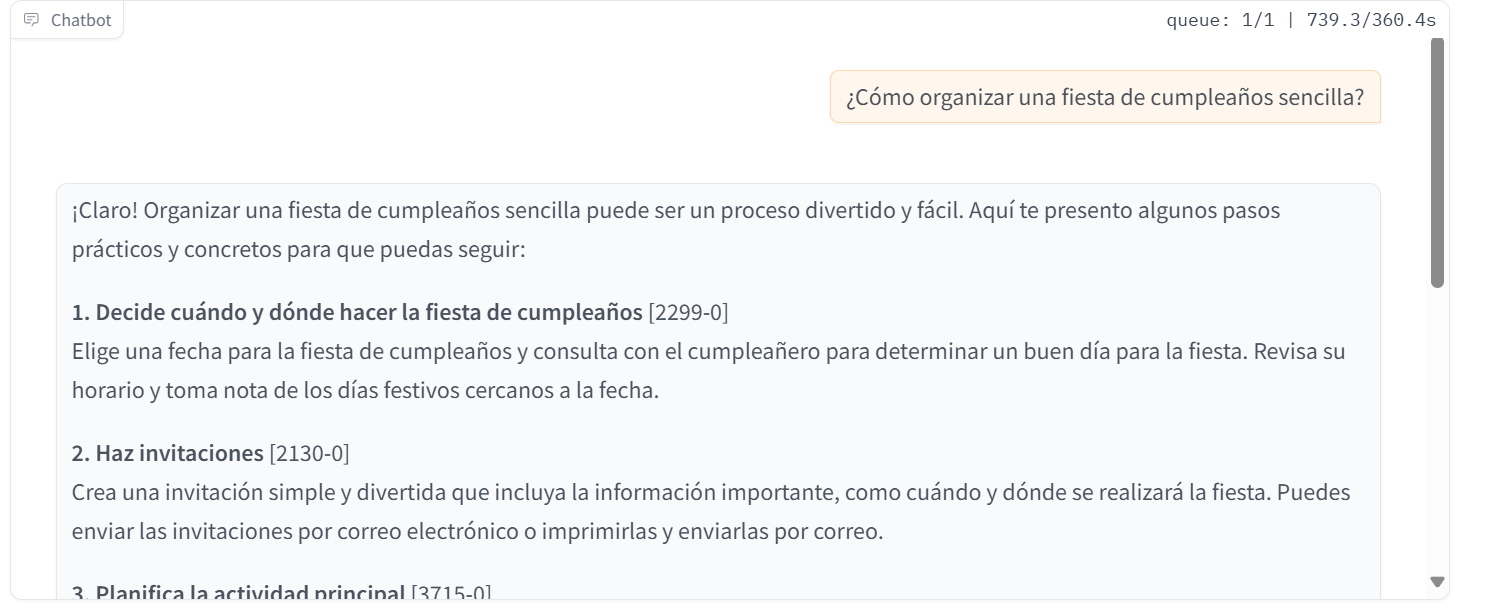

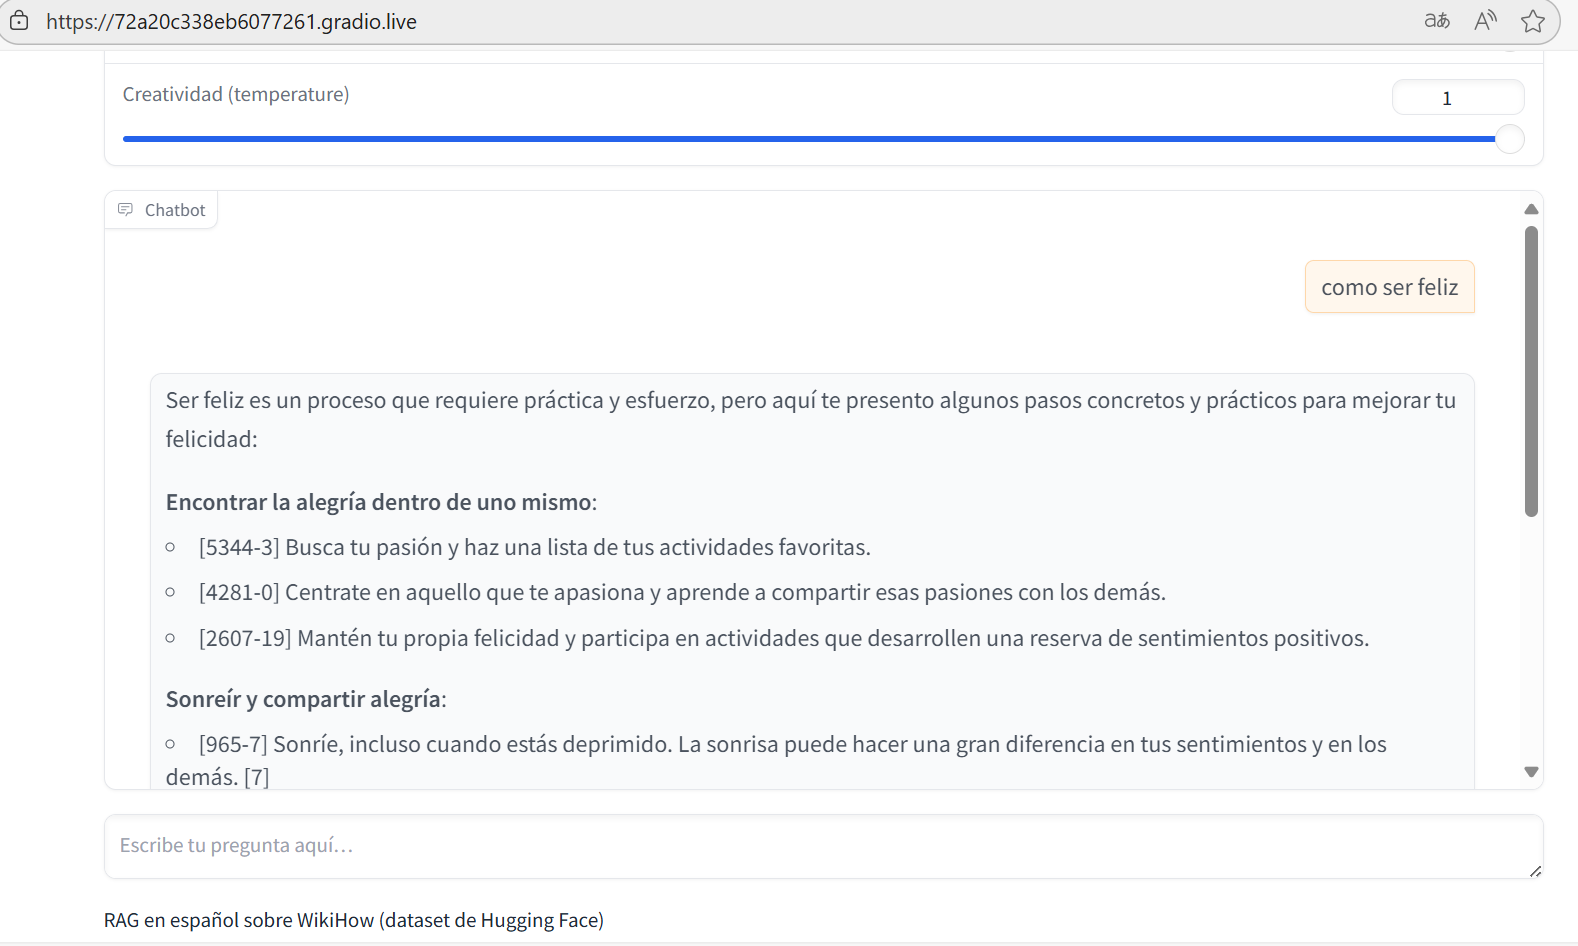

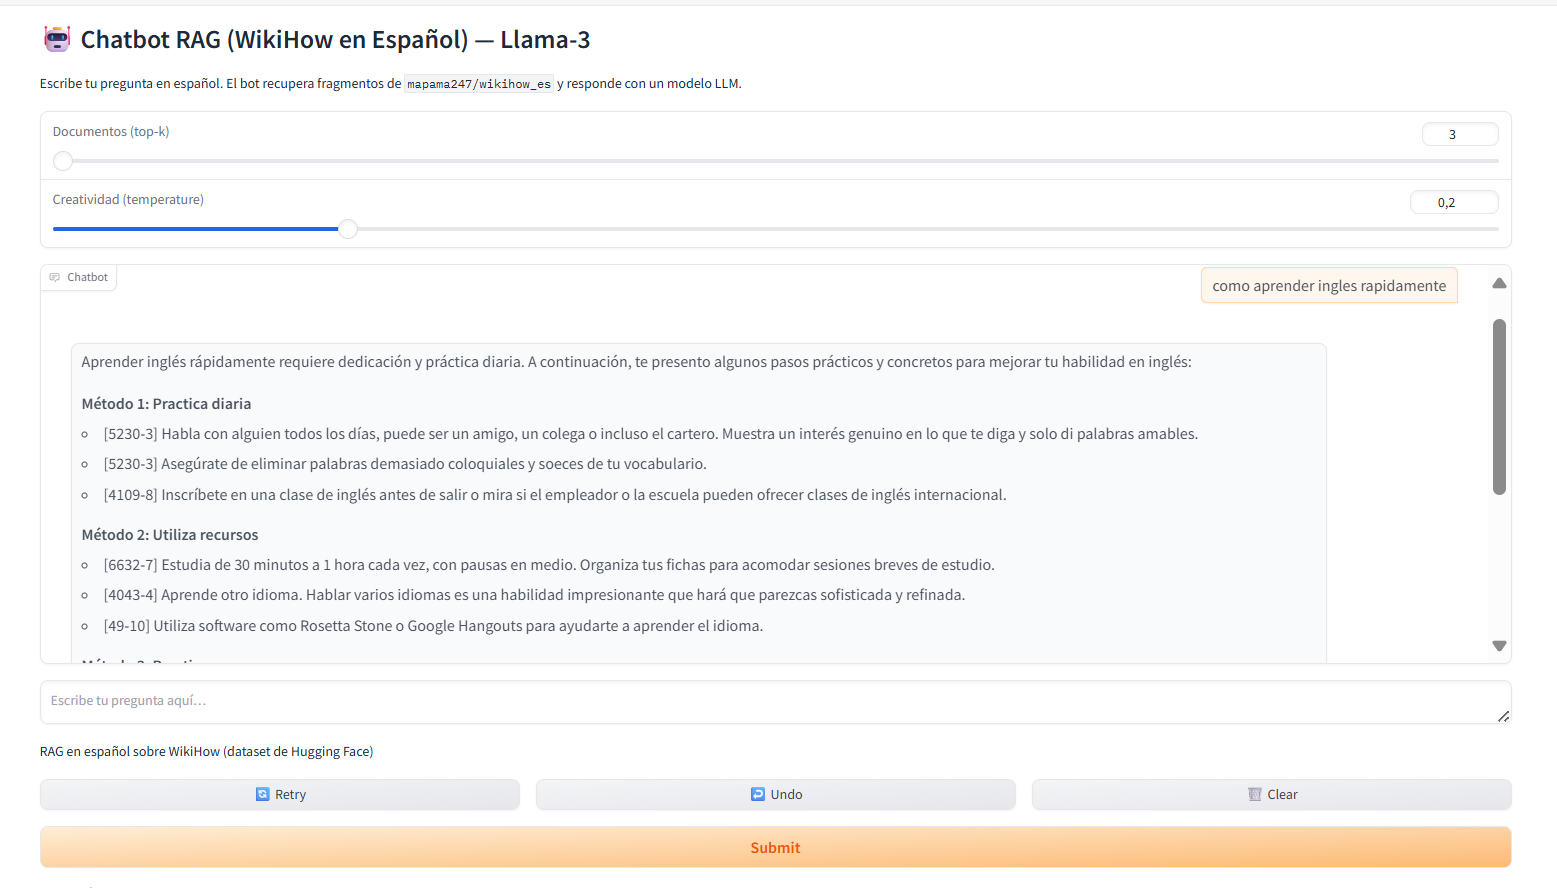

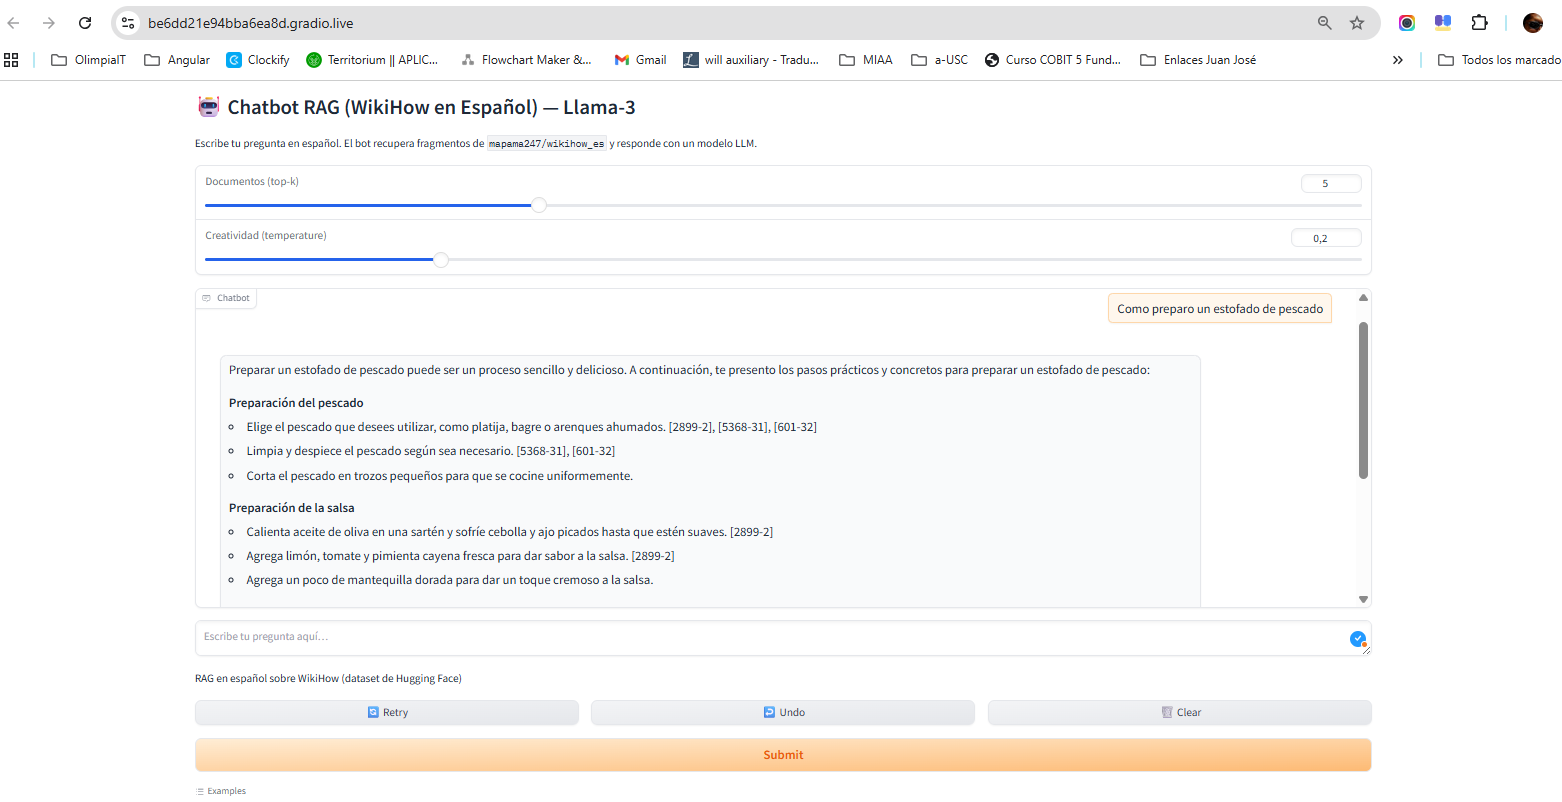

## 9) Conclusiones

1. **Latencia de las respuestas:**
Durante las pruebas notamos que el modelo no responde de forma inmediata, ya que primero busca la información en los fragmentos y después genera la respuesta con el LLM. Esto hace que tarde algunos segundos, especialmente si se aumentan los documentos recuperados (top-k).

2. **Calidad de la información**
El modelo generalmente entrega respuestas claras y útiles, porque se apoya en los textos de WikiHow. Además, cuando cita el fragmento de donde saca la información, da más confianza en lo que está diciendo.

3. **Flexibilidad para el usuario**
Es positivo que se puedan ajustar parámetros como la cantidad de documentos a recuperar y la creatividad de las respuestas. Esto permite controlar si queremos algo más preciso o algo más variado en las recomendaciones.

4. **Facilidad de uso**
La interfaz en Gradio hace que sea sencillo interactuar con el modelo, incluso sin conocimientos técnicos. Con solo escribir la pregunta en español y mover los controles, cualquier persona puede probar el sistema sin necesidad de programar

5. **Consumo de recursos RAM**
Se identifica que al disminuir el numero de Chunks, durante el procesamiento del vector se aumenta considerablemente el consumo de memoria RAM, se realiza la prueba con 100, y superó los 12 GB de RAM que ofrece el entorno de COLAB (Free), debido a esto se ajusta el tamaño de los chunks a 300 y el hiperparámetro overlap a 100, logrando poder continuar con el procesamiento. No obstante el momento de generar la consulta en el chat vemos que se impacta directamente el tiempo de latencia en generar la respuesta.


- **Dataset**: `mapama247/wikihow_es` (Hugging Face)
- **Modelo**: Llama‑3 (Meta).